In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Stack

In [72]:
df_single_level_cols = pd.DataFrame([[0, 1], [2, 3]],
                                    index=['cat', 'dog'],
                                    columns=['weight', 'height'])

In [73]:
df_single_level_cols

,weight,height
cat,0,1
dog,2,3


In [74]:
df_single_level_cols.stack(0)

cat  weight    0
     height    1
dog  weight    2
     height    3
dtype: int64

## Pivot

In [75]:
df = pd.DataFrame({'foo': ['one', 'one', 'one', 'two', 'two',
                           'two'],
                   'bar': ['A', 'B', 'C', 'A', 'B', 'C'],
                   'baz': [1, 2, 3, 4, 5, 6],
                   'zoo': ['x', 'y', 'z', 'q', 'w', 't']})
df

,foo,bar,baz,zoo
0,one,A,1,x
1,one,B,2,y
2,one,C,3,z
3,two,A,4,q
4,two,B,5,w
5,two,C,6,t


In [76]:
df.pivot(index='foo', columns='bar', values='baz')

bar,A,B,C
foo,,,
one,1,2,3
two,4,5,6


In [77]:
df.pivot(index='foo', columns='bar')

baz       zoo      
bar   A  B  C   A  B  C
foo                    
one   1  2  3   x  y  z
two   4  5  6   q  w  t

In [78]:
df.pivot(index='foo', columns='bar', values=['baz', 'zoo'])


baz       zoo      
bar   A  B  C   A  B  C
foo                    
one   1  2  3   x  y  z
two   4  5  6   q  w  t

In [80]:
date_range = pd.date_range(start="2010-01-01", periods=365*5, freq="D")
returns = pd.DataFrame(np.random.normal(0, 0.0030, 365*5), index=date_range, columns=["returns"])

In [81]:
returns.head(5)

,returns
2010-01-01,0.003241
2010-01-02,-0.006122
2010-01-03,0.002279
2010-01-04,0.001223
2010-01-05,0.001293


In [126]:
returns["month"] = returns.index.month
returns["year"] = returns.index.year
returns["day"] = returns.index.day

In [90]:
returns["2010-02-01":] 

,returns,month,year
2010-02-01,-0.001725,2,2010
2010-02-02,-0.002988,2,2010
2010-02-03,-0.001989,2,2010
2010-02-04,0.001945,2,2010
2010-02-05,-0.001899,2,2010
...,...,...,...
2014-12-26,0.003909,12,2014
2014-12-27,-0.002099,12,2014
2014-12-28,-0.002755,12,2014
2014-12-29,0.002916,12,2014


In [91]:
returns.head(5)

,returns,month,year
2010-01-01,0.003241,1,2010
2010-01-02,-0.006122,1,2010
2010-01-03,0.002279,1,2010
2010-01-04,0.001223,1,2010
2010-01-05,0.001293,1,2010


/tmp/ipykernel_330478/1250010494.py:3: FutureWarning: Indexing a DataFrame with a datetimelike index using a single string to slice the rows, like `frame[string]`, is deprecated and will be removed in a future version. Use `frame.loc[string]` instead.
  returns.pivot(columns=["month", "day"], values=["returns"])["returns"][month]["2012"].plot(alpha=0.8, ax=ax[month-1])
/tmp/ipykernel_330478/1250010494.py:3: FutureWarning: Indexing a DataFrame with a datetimelike index using a single string to slice the rows, like `frame[string]`, is deprecated and will be removed in a future version. Use `frame.loc[string]` instead.
  returns.pivot(columns=["month", "day"], values=["returns"])["returns"][month]["2012"].plot(alpha=0.8, ax=ax[month-1])
/tmp/ipykernel_330478/1250010494.py:3: FutureWarning: Indexing a DataFrame with a datetimelike index using a single string to slice the rows, like `frame[string]`, is deprecated and will be removed in a future version. Use `frame.loc[string]` instead.
  re

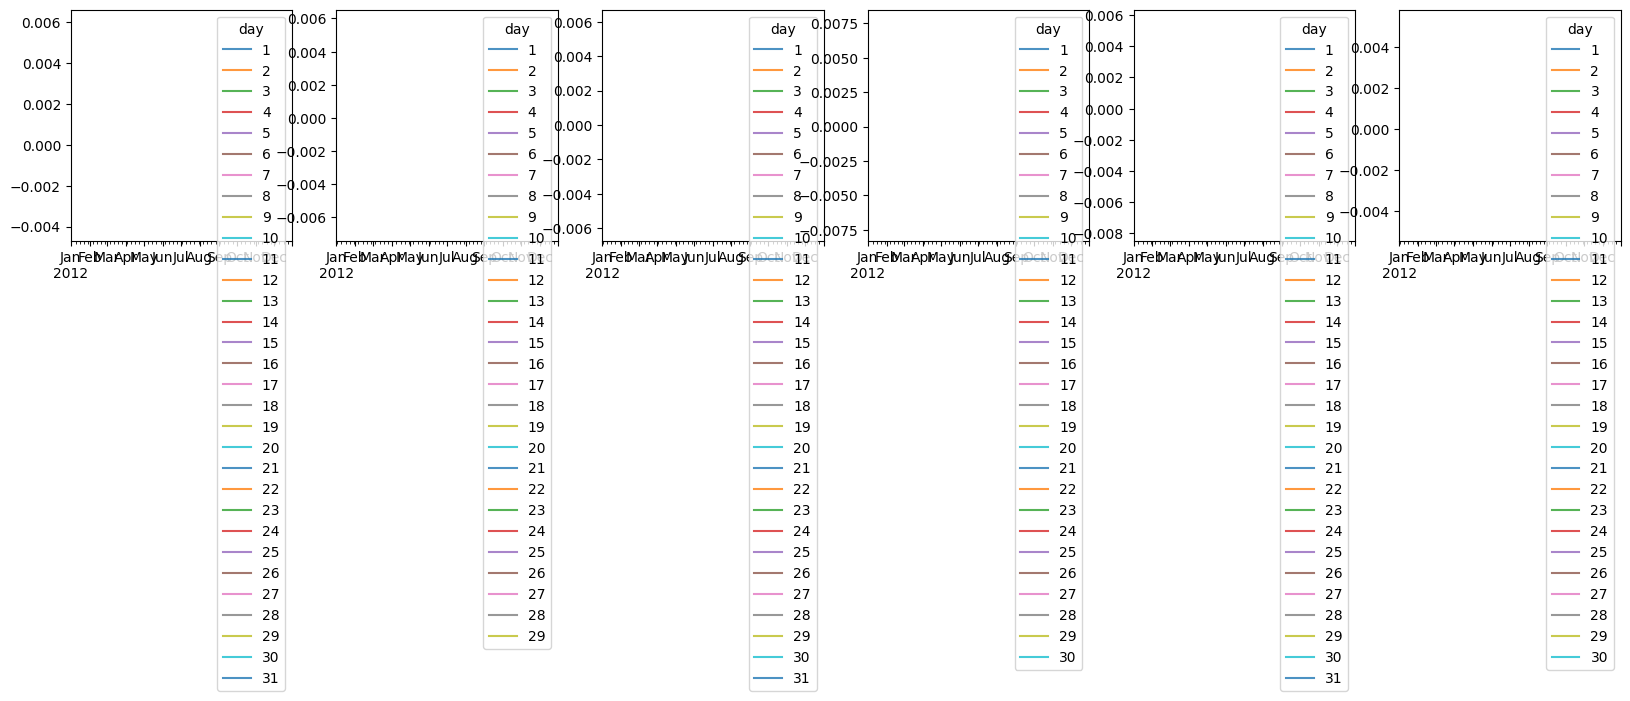

In [127]:
fig, ax = plt.subplots(1,6, figsize=(20,3))
for month in range(1, 7):
    returns.pivot(columns=["month"], values=["returns"])["returns"][month]["2012"].plot(alpha=0.8, ax=ax[month-1])

plt.show()


In [112]:
returns.pivot( columns=["month"], values=["returns"]).mean()

         month
returns  1       -0.000098
         2       -0.000653
         3        0.000245
         4        0.000216
         5       -0.000236
         6        0.000361
         7        0.000108
         8       -0.000005
         9       -0.000022
         10       0.000147
         11       0.000219
         12       0.000169
dtype: float64

In [135]:
returns.pivot(columns=["year", "month", "day"], values=["returns"])

returns                                                          \
year            2010                                                           
month             1                                                            
day               1         2         3         4         5   6   7   8   9    
2010-01-01  0.003241       NaN       NaN       NaN       NaN NaN NaN NaN NaN   
2010-01-02       NaN -0.006122       NaN       NaN       NaN NaN NaN NaN NaN   
2010-01-03       NaN       NaN  0.002279       NaN       NaN NaN NaN NaN NaN   
2010-01-04       NaN       NaN       NaN  0.001223       NaN NaN NaN NaN NaN   
2010-01-05       NaN       NaN       NaN       NaN  0.001293 NaN NaN NaN NaN   
...              ...       ...       ...       ...       ...  ..  ..  ..  ..   
2014-12-26       NaN       NaN       NaN       NaN       NaN NaN NaN NaN NaN   
2014-12-27       NaN       NaN       NaN       NaN       NaN NaN NaN NaN NaN   
2014-12-28       NaN       NaN       NaN       NaN       NaN NaN NaN NaN NaN   
2014-12-29       NaN       NaN       NaN       NaN       NaN NaN NaN NaN NaN   
2014-12-30       NaN       NaN       NaN       NaN       NaN NaN NaN NaN NaN   

                ...                                                     \
year            ... 2014                                                 
month           ...   12                                                 
day         10  ...   21  22  23  24  25        26        27        28   
2010-01-01 NaN  ...  NaN NaN NaN NaN NaN       NaN       NaN       NaN   
2010-01-02 NaN  ...  NaN NaN NaN NaN NaN       NaN       NaN       NaN   
2010-01-03 NaN  ...  NaN NaN NaN NaN NaN       NaN       NaN       NaN   
2010-01-04 NaN  ...  NaN NaN NaN NaN NaN       NaN       NaN       NaN   
2010-01-05 NaN  ...  NaN NaN NaN NaN NaN       NaN       NaN       NaN   
...         ..  ...  ...  ..  ..  ..  ..       ...       ...       ...   
2014-12-26 NaN  ...  NaN NaN NaN NaN NaN  0.003909       NaN       NaN   
2014-12-27 NaN  ...  NaN NaN NaN NaN NaN       NaN -0.002099       NaN   
2014-12-28 NaN  ...  NaN NaN NaN NaN NaN       NaN       NaN -0.002755   
2014-12-29 NaN  ...  NaN NaN NaN NaN NaN       NaN       NaN       NaN   
2014-12-30 NaN  ...  NaN NaN NaN NaN NaN       NaN       NaN       NaN   

                                
year                            
month                           
day               29        30  
2010-01-01       NaN       NaN  
2010-01-02       NaN       NaN  
2010-01-03       NaN       NaN  
2010-01-04       NaN       NaN  
2010-01-05       NaN       NaN  
...              ...       ...  
2014-12-26       NaN       NaN  
2014-12-27       NaN       NaN  
2014-12-28       NaN       NaN  
2014-12-29  0.002916       NaN  
2014-12-30       NaN  0.003306  

[1825 rows x 1825 columns]